# Testing AMPKAR quantities of interest: Mass-action kinetics, double binding 

Nathaniel Linden (UCSD MAE) - May  2023

In [1]:
import numpy as np
import os
import sys

import jax  
import jax.numpy as jnp
import jax.scipy as jsp
import scipy.optimize as opt
from jax import lax
import equinox as eqx
import diffrax as dfrx

import matplotlib.pyplot as plt
import matplotlib as mpl
import pandas as pd
from scipy.stats import t
import ipywidgets as widgets

jax.config.update('jax_enable_x64', True)
sys.path.insert(0, '../odes')
import ampk_newmech_MA_single_diffrax as model
import ampk_newmech_MA_single as model1
from gsa_utils import *
import gsa_utils

%matplotlib inline
# plt.style.use('~/.matplotlib/custom.mplstyle')
# mpl.rcParams['figure.autolayout'] = True

### Load the parameter values
Here, we define two sets of bounds on the parameters. The first uses a $\pm 50 \%$ interval, while the second uses more extreme upper and lower bounds for some of the parameters. We chose the more extreme bounds for these parameters to ensure that we are covering all possible physiological values for these parameters.

In [65]:
MA_nominals = pd.read_csv('nominal_params_newmech_MA.csv')
MM_nominals = pd.read_csv('nominal_params_newmech_MM.csv')
nominal_vals_MA = MA_nominals['value'].to_list()
param_names_MA = MA_nominals['parameter'].to_list()

# bounds and problem dicts for SALib
lb_mult = 0.00001
ub_mult = 100.0
bounds_MA = [[lb_mult*param, ub_mult*param] for param in nominal_vals_MA]

Set up the necesary overhead for solving the model.

In [66]:
# states and initial conditions
state_names = ['AMP', 'ADP', 'ATP',
               'AMPK', 'pAMPK', 
               'AMP_AMPK', 'AMP_pAMPK',
               'CaMKK', 'CaMKK_AMPK', 'CaMKK_AMP_AMPK',
               'LKB1', 'LKB1_AMPK', 'LKB1_AMP_AMPK',
               'PP', 'PP_pAMPK', 
               'AMPKAR', 'pAMPKAR', 'AMPKAR_pAMPK', 'AMPKAR_AMP_pAMPK', 
               'PP1', 'PP1_pAMPKAR']

ampkar_idx = state_names.index('AMPKAR')
pampkar_idx = state_names.index('pAMPKAR')


# Set initial conditions
to_set = ['AMP', 'ADP', 'ATP', 'AMPK', 'CaMKK', 'LKB1', 'PP', 'AMPKAR', 'PP1']
idxs = [state_names.index(item) for item in to_set]
y0 = np.zeros((53,))
y0[idxs[0]] = 2e-2   # AMP
y0[idxs[1]] = 1.3 # ADP
y0[idxs[2]] = 8.2   # ATP
y0[idxs[3]] = 1.0   # AMPK
y0[idxs[4]] = 1.0   # CaMKK
y0[idxs[5]] = 1.0   # LKB1
y0[idxs[6]] = 1.0   # PP
y0[idxs[7]] = 0.1   # AMPKAR
y0[idxs[8]] = 1.0   # PP1

y0 = np.array(y0)

# parameters
# metabolism_params
metab_parms_basal = {'kGly': 0.5,'kHydro':0.1,
                     'VforAK': 14.66, 'KeqAK': 2.21, 'kmm': 0.32, 'kmd': 0.35, 'kmt': 0.27,
                     'VmaxOxPhos':0.5,'Kadp': 5.8e-2,'n': 2.568,}
metab_parms_stress = {'kGly': 0.005,'kHydro':0.1,
                      'VforAK': 14.66, 'KeqAK': 2.21, 'kmm': 0.32, 'kmd': 0.35, 'kmt': 0.27,
                     'VmaxOxPhos':0.5,'Kadp': 5.8e-2,'n': 2.568,}

## Now test a solve to steady-state function
@jax.jit
def solve_model(params, rhs, y0, t1, times):
    y0 = y0.at[ampkar_idx].set(params[-2])
    params = compute_newmech_MA_params(params)
    solver=dfrx.Kvaerno5()
    stepsize_controller = dfrx.PIDController(rtol=1e-10, atol=1e-10)
    t0 = 0.0
    # times = jnp.arange(t0, t1, 0.5)
    dt0 = 1e-8 # initial time step
    saveat=dfrx.SaveAt(ts=times)

    # initial solve
    sol = dfrx.diffeqsolve(
        rhs, 
        solver, 
        t0, t1, dt0, 
        y0, 
        saveat=saveat, 
        stepsize_controller=stepsize_controller,
        args=params)
    
    return sol # returns the final state

################################################
#                   Model RHS                  #
################################################
rhs = model.ampk_newmech_MA_single(**metab_parms_basal)
rhs_stress = model.ampk_newmech_MA_single(**metab_parms_stress)
rhs = dfrx.ODETerm(rhs)
rhs_stress = dfrx.ODETerm(rhs_stress)

# run once to compile
times = jnp.arange(0.0, 1000.0, 0.5)
sol = solve_model(nominal_vals_MA, rhs_stress, y0, 1000.0, times)

In [71]:
amp_states = ['AMP', 'AMP_AMPK', 'AMP_pAMPK',
               'CaMKK_AMP_AMPK', 'LKB1_AMP_AMPK',
               'AMPKAR_AMP_pAMPK']
adp_states = ['ADP']
atp_states = ['ATP']
ampk_states = ['AMPK', 'pAMPK', 'AMP_AMPK', 'AMP_pAMPK',
               'CaMKK_AMPK', 'CaMKK_AMP_AMPK','LKB1_AMPK', 'LKB1_AMP_AMPK',
               'PP_pAMPK', 'AMPKAR_pAMPK', 'AMPKAR_AMP_pAMPK']
pampk_states = ['pAMPK', 'AMP_pAMPK', 'pAMPK', 'pAMPK', 'AMP_pAMPK','AMPKAR_pAMPK', 'AMPKAR_AMP_pAMPK']
ampkar_states = ['AMPKAR', 'pAMPKAR', 'AMPKAR_pAMPK', 'AMPKAR_AMP_pAMPK', 'PP1_pAMPKAR']
pampkar_states = ['pAMPKAR', 'PP1_pAMPKAR']

amp_idxs = [state_names.index(item) for item in amp_states]
adp_idxs = [state_names.index(item) for item in adp_states]
atp_idxs = [state_names.index(item) for item in atp_states]
ampk_idxs = [state_names.index(item) for item in ampk_states]
pampk_idxs = [state_names.index(item) for item in pampk_states]
ampkar_idxs = [state_names.index(item) for item in ampkar_states]
pampkar_idxs = [state_names.index(item) for item in pampkar_states]

Define a function that takes all of the variable model parameters as arguments, along with the QoI and plots the quantities of interest.

In [72]:
def update_plot(KdAMP, kOnCaMKK, kPhosCaMKK, kOnLKB1, kPhosLKB1, kOnPP, kDephosPP, kOnAMPK, kPhosAMPK, kOnPP1, kDephosPP1, AMPKAR_0, beta):
    sample = np.array([KdAMP, kOnCaMKK, kPhosCaMKK, kOnLKB1, kPhosLKB1, kOnPP, kDephosPP, kOnAMPK, kPhosAMPK, kOnPP1, kDephosPP1, AMPKAR_0, beta])
    
    # run the model to initial steady-state
    tmax = 1e5
    times = jnp.arange(0.0, tmax, tmax/1000)
    sol_basal = solve_model(sample, rhs, y0, tmax, times)
    # now actually run to get a solution
    # note sol[0] will be the ic and sol[1] will be the time to steady-state
    times = jnp.arange(0.0, tmax, tmax/1000)
    sol_stress = solve_model(sample, rhs_stress, sol_basal.ys[-1,:], tmax, times)

    fig, ax = plt.subplots(2, 2, figsize=(6, 4))
    # pAMPKAR
    AMPKAR_tot_basal =  np.sum(sol_basal.ys[:,ampkar_idxs], axis=1)
    AMPKAR_tot_stress =  np.sum(sol_stress.ys[:,ampkar_idxs], axis=1)
    pampkar_basal = np.sum(sol_basal.ys[:,pampkar_idxs], axis=1)
    pampkar_stress = np.sum(sol_stress.ys[:,pampkar_idxs], axis=1)
    # ax[0][0].plot(sol_basal.ts, pampkar_basal/AMPKAR_tot_basal, 'k')
    # ax[0][0].plot(sol_basal.ts[-1]+sol_stress.ts, pampkar_stress/AMPKAR_tot_basal, 'b')
    ax[0][0].plot(sol_stress.ts, 
                  (pampkar_stress/AMPKAR_tot_basal)-(pampkar_basal[-1]/AMPKAR_tot_basal[-1]), 'b')
    ax[0][0].set_ylim([1e-4, 1.1e0])
    ax[0][0].set_ylabel(r'$pAMPKAR/AMPKAR_{tot}$')
    ax[0][0].set_xlabel('time (s)')
    # ax[0][0].set_xlim([0.0, 2*tmax])

    # Adenine nucleotide ratios
    AMP_tot_basal = sum([sol_basal.ys[:,idx] for idx in amp_idxs])
    ADP_tot_basal = sum([sol_basal.ys[:,idx] for idx in adp_idxs])
    ATP_tot_basal = sum([sol_basal.ys[:,idx] for idx in atp_idxs])
    AMP_tot_stress = sum([sol_stress.ys[:,idx] for idx in amp_idxs])
    ADP_tot_stress = sum([sol_stress.ys[:,idx] for idx in adp_idxs])
    ATP_tot_stress = sum([sol_stress.ys[:,idx] for idx in atp_idxs])
    
    ax[1][0].plot(np.hstack((sol_basal.ts, sol_basal.ts[-1]+sol_stress.ts)), 
             np.hstack((ATP_tot_basal/AMP_tot_basal, ATP_tot_stress/AMP_tot_stress)), 'b', linewidth=2.5)
    ax[1][0].plot(np.hstack((sol_basal.ts, sol_basal.ts[-1]+sol_stress.ts)), 
             np.hstack((ATP_tot_basal/ADP_tot_basal, ATP_tot_stress/ADP_tot_stress)), 'k:', linewidth=2.5)
    ylims = ax[1][0].get_ylim()
    ax[1][0].fill_between(np.arange(sol_basal.ts[-1], sol_basal.ts[-1]+sol_stress.ts[-1]), 
                            ylims[0], ylims[-1], color='grey', alpha=0.5, lw=0)
    ax[1][0].set_yscale('log')
    ax[1][0].set_ylabel('adenine nucleotide ratio')
    ax[1][0].set_xlabel('time (s)')
    ax[1][0].legend(('ATP:AMP', 'ATP:ADP'))

    # pAMPKAR
    AMPK_tot_basal =  np.sum(sol_basal.ys[:,ampk_idxs], axis=1)
    AMPK_tot_stress =  np.sum(sol_stress.ys[:,ampk_idxs], axis=1)
    pampk_basal = np.sum(sol_basal.ys[:,pampk_idxs], axis=1)
    pampk_stress = np.sum(sol_stress.ys[:,pampk_idxs], axis=1)
    ax[0][1].plot(sol_basal.ts, pampk_basal/AMPK_tot_basal, 'k')
    ax[0][1].plot(sol_basal.ts[-1]+sol_stress.ts, pampk_stress/AMPK_tot_basal, 'b')
    ax[0][1].set_ylim([1e-4, 1.1e1])
    ax[0][1].set_ylabel(r'$pAMPK/AMPK_{tot}$')
    ax[0][1].set_xlabel('time (s)')
    ax[0][1].set_xlim([0.0, 2*tmax])

    # pAMPK
    pampk_basal = np.sum(sol_basal.ys[:,pampk_idxs], axis=1)
    pampk_stress = np.sum(sol_stress.ys[:,pampk_idxs], axis=1)
    ax[1][1].plot(sol_basal.ts, pampk_basal, 'k')
    ax[1][1].plot(sol_basal.ts[-1]+sol_stress.ts, pampk_stress, 'b')
    ax[1][1].set_ylim([1e-4, 1e1])
    ax[1][1].set_ylabel(r'$pAMPK$')
    ax[1][1].set_xlabel('time (s)')
    ax[1][1].set_xlim([0.0, 2*tmax])

    plt.show()

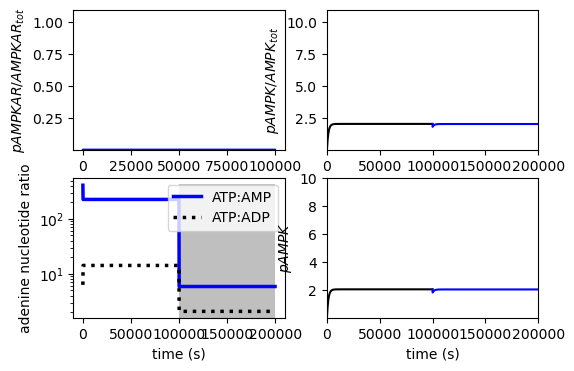

In [73]:
update_plot(nominal_vals_MA[0], nominal_vals_MA[1], nominal_vals_MA[2], nominal_vals_MA[3], nominal_vals_MA[4],
           nominal_vals_MA[5], nominal_vals_MA[6], nominal_vals_MA[7], nominal_vals_MA[8], nominal_vals_MA[9],
           nominal_vals_MA[10], nominal_vals_MA[11], nominal_vals_MA[12])

In [74]:
KdAMP_slider = widgets.FloatSlider(min=bounds_MA[0][0], max=bounds_MA[0][1], 
                                      value=nominal_vals_MA[0], 
                                      description=param_names_MA[0],
                                      step=1e-8, continous_update=True, 
                                      readout_format='.8f')
kOnCaMKK_slider = widgets.FloatSlider(min=bounds_MA[1][0], max=bounds_MA[1][1], 
                                      value=nominal_vals_MA[1], 
                                      description=param_names_MA[1],
                                      step=1e-8, continous_update=True,
                                      readout_format='.4f')
kPhosCaMKK_slider = widgets.FloatSlider(min=bounds_MA[2][0], max=bounds_MA[2][1], 
                                      value=nominal_vals_MA[2], 
                                      description=param_names_MA[2],
                                      step=1e-8, continous_update=True,
                                      readout_format='.4f')
kOnLKB1_slider = widgets.FloatSlider(min=bounds_MA[3][0], max=bounds_MA[3][1], 
                                      value=nominal_vals_MA[3], 
                                      description=param_names_MA[3],
                                      step=1e-8, continous_update=True,
                                      readout_format='.4f')
kPhosLKB1_slider = widgets.FloatSlider(min=bounds_MA[4][0], max=bounds_MA[4][1], 
                                      value=nominal_vals_MA[4], 
                                      description=param_names_MA[4],
                                      step=1e-8, continous_update=True,
                                      readout_format='.4f')
kOnPP_slider = widgets.FloatSlider(min=bounds_MA[5][0], max=bounds_MA[5][1], 
                                      value=nominal_vals_MA[5], 
                                      description=param_names_MA[5],
                                      step=1e-8, continous_update=True,
                                      readout_format='.4f')
kDephosPP_slider = widgets.FloatSlider(min=bounds_MA[6][0], max=bounds_MA[6][1], 
                                      value=nominal_vals_MA[6], 
                                      description=param_names_MA[6],
                                      step=1e-8, continous_update=True,
                                      readout_format='.4f')
kOnAMPK_slider = widgets.FloatSlider(min=bounds_MA[7][0], max=bounds_MA[7][1], 
                                      value=nominal_vals_MA[7], 
                                      description=param_names_MA[7],
                                      step=1e-8, continous_update=True,
                                      readout_format='.4f')
kPhosAMPK_slider = widgets.FloatSlider(min=bounds_MA[8][0], max=bounds_MA[8][1], 
                                      value=nominal_vals_MA[8], 
                                      description=param_names_MA[8],
                                      step=1e-8, continous_update=True,
                                      readout_format='.4f')
kOnPP1_slider = widgets.FloatSlider(min=bounds_MA[9][0], max=bounds_MA[9][1], 
                                      value=nominal_vals_MA[9], 
                                      description=param_names_MA[9],
                                      step=1e-8, continous_update=True,
                                      readout_format='.4f')
kDephosPP1_slider = widgets.FloatSlider(min=bounds_MA[10][0], max=bounds_MA[10][1], 
                                      value=nominal_vals_MA[10], 
                                      description=param_names_MA[10],
                                      step=1e-8, continous_update=True,
                                      readout_format='.4f')
AMPKAR_0_slider = widgets.FloatSlider(min=bounds_MA[11][0], max=bounds_MA[11][1], 
                                      value=nominal_vals_MA[11], 
                                      description=param_names_MA[11],
                                      step=1e-8, continous_update=True, 
                                      readout_format='.4f')
beta_slider = widgets.FloatSlider(min=bounds_MA[12][0], max=bounds_MA[12][1], 
                                      value=nominal_vals_MA[12], 
                                      description=param_names_MA[12],
                                      step=1e-8, continous_update=True, 
                                      readout_format='.4f')

widget = widgets.interactive(update_plot, KdAMP=KdAMP_slider, kOnCaMKK=kOnCaMKK_slider, kPhosCaMKK=kPhosCaMKK_slider,
                             kOnLKB1=kOnLKB1_slider, kPhosLKB1=kPhosLKB1_slider, 
                             kOnPP=kOnPP_slider, kDephosPP=kDephosPP_slider,
                             kOnAMPK=kOnAMPK_slider, kPhosAMPK=kPhosAMPK_slider,
                             kOnPP1=kOnPP1_slider, kDephosPP1=kDephosPP1_slider,
                             AMPKAR_0=AMPKAR_0_slider, beta=beta_slider)
display(widget)


interactive(children=(FloatSlider(value=0.0025, description='KdAMP', max=0.25, min=2.5000000000000002e-08, rea…

In [21]:
a = np.array([[3.0,2.0,3.0],
              [1.0,2.0,3.0],
              [1.0,2.0,3.0]])
idxs = [0,2]
np.sum(a[idxs,:],axis=0)

array([4., 4., 6.])